In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from pathlib import Path
from matplotlib import font_manager


In [3]:
CSV_PATH   = "C:\\Users\\anath\\2026LastSemester\\gen8ou-1825\\gen8ouExtras.csv"
FOCAL_MONTH = "2022-10"   # swap this to any month in the dataset
CUTOFF     = 5.0          # minimum usage % for the bar chart
 
df = pd.read_csv(CSV_PATH)
 
# usage is a decimal (e.g. 0.312); convert to percent
df["usage_pct"] = df["usage"] * 100
 
# ── per-pokemon summary stats across ALL months ──────────────────────────────
summary = (
    df.groupby("pokemon")["usage_pct"]
    .agg(mean_percent="mean", sd_percent="std")
    .fillna(0)
    .reset_index()
)
SAVE_DIR = Path("gen8ou_graphs_Lab_6") 
SAVE_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
def _q25(x): return x.quantile(0.25)
def _q75(x): return x.quantile(0.75)

med_summary = (
    df.groupby("pokemon")["usage_pct"]
    .agg(med_percent="median", med_iqr_low=_q25, med_iqr_high=_q75)
    .reset_index()
)

med_focal = (
    df[df["month"] == FOCAL_MONTH][["pokemon", "usage_pct"]]
    .rename(columns={"usage_pct": "med_focal_percent"})
)

med_plot_df = med_focal.merge(med_summary, on="pokemon", how="left").fillna(0)

tm_MIN_USAGE = 1.0

tm_means = df.groupby("pokemon")["usage_pct"].mean().reset_index().rename(
    columns={"usage_pct": "mean_pct"}
)
tm_full = med_summary.merge(tm_means, on="pokemon", how="left")
tm_full["iqr"] = tm_full["med_iqr_high"] - tm_full["med_iqr_low"]

tm_named = tm_full[tm_full["med_percent"] >= tm_MIN_USAGE].copy()
tm_other = tm_full[tm_full["med_percent"] <  tm_MIN_USAGE].copy()

tm_other_row = pd.DataFrame([{
    "pokemon":     f"Other\n({len(tm_other)} Pokémon)",
    "med_percent": tm_other["med_percent"].sum(),
    "mean_pct":    tm_other["mean_pct"].sum(),
    "iqr":         np.nan,
}])

tm_df = pd.concat([tm_named, tm_other_row], ignore_index=True)
tm_first_month = df["month"].min()
tm_last_month  = df["month"].max()
tm_in_first    = set(df[df["month"] == tm_first_month]["pokemon"])
tm_in_last     = set(df[df["month"] == tm_last_month]["pokemon"])
tm_legal       = tm_in_first & tm_in_last

tm_df = tm_df[
    tm_df["pokemon"].isin(tm_legal) | tm_df["pokemon"].str.startswith("Other")
].copy()

C:\Users\Anath\AppData\Local\Temp\ipykernel_42572\56108395.py:180: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("Blues")


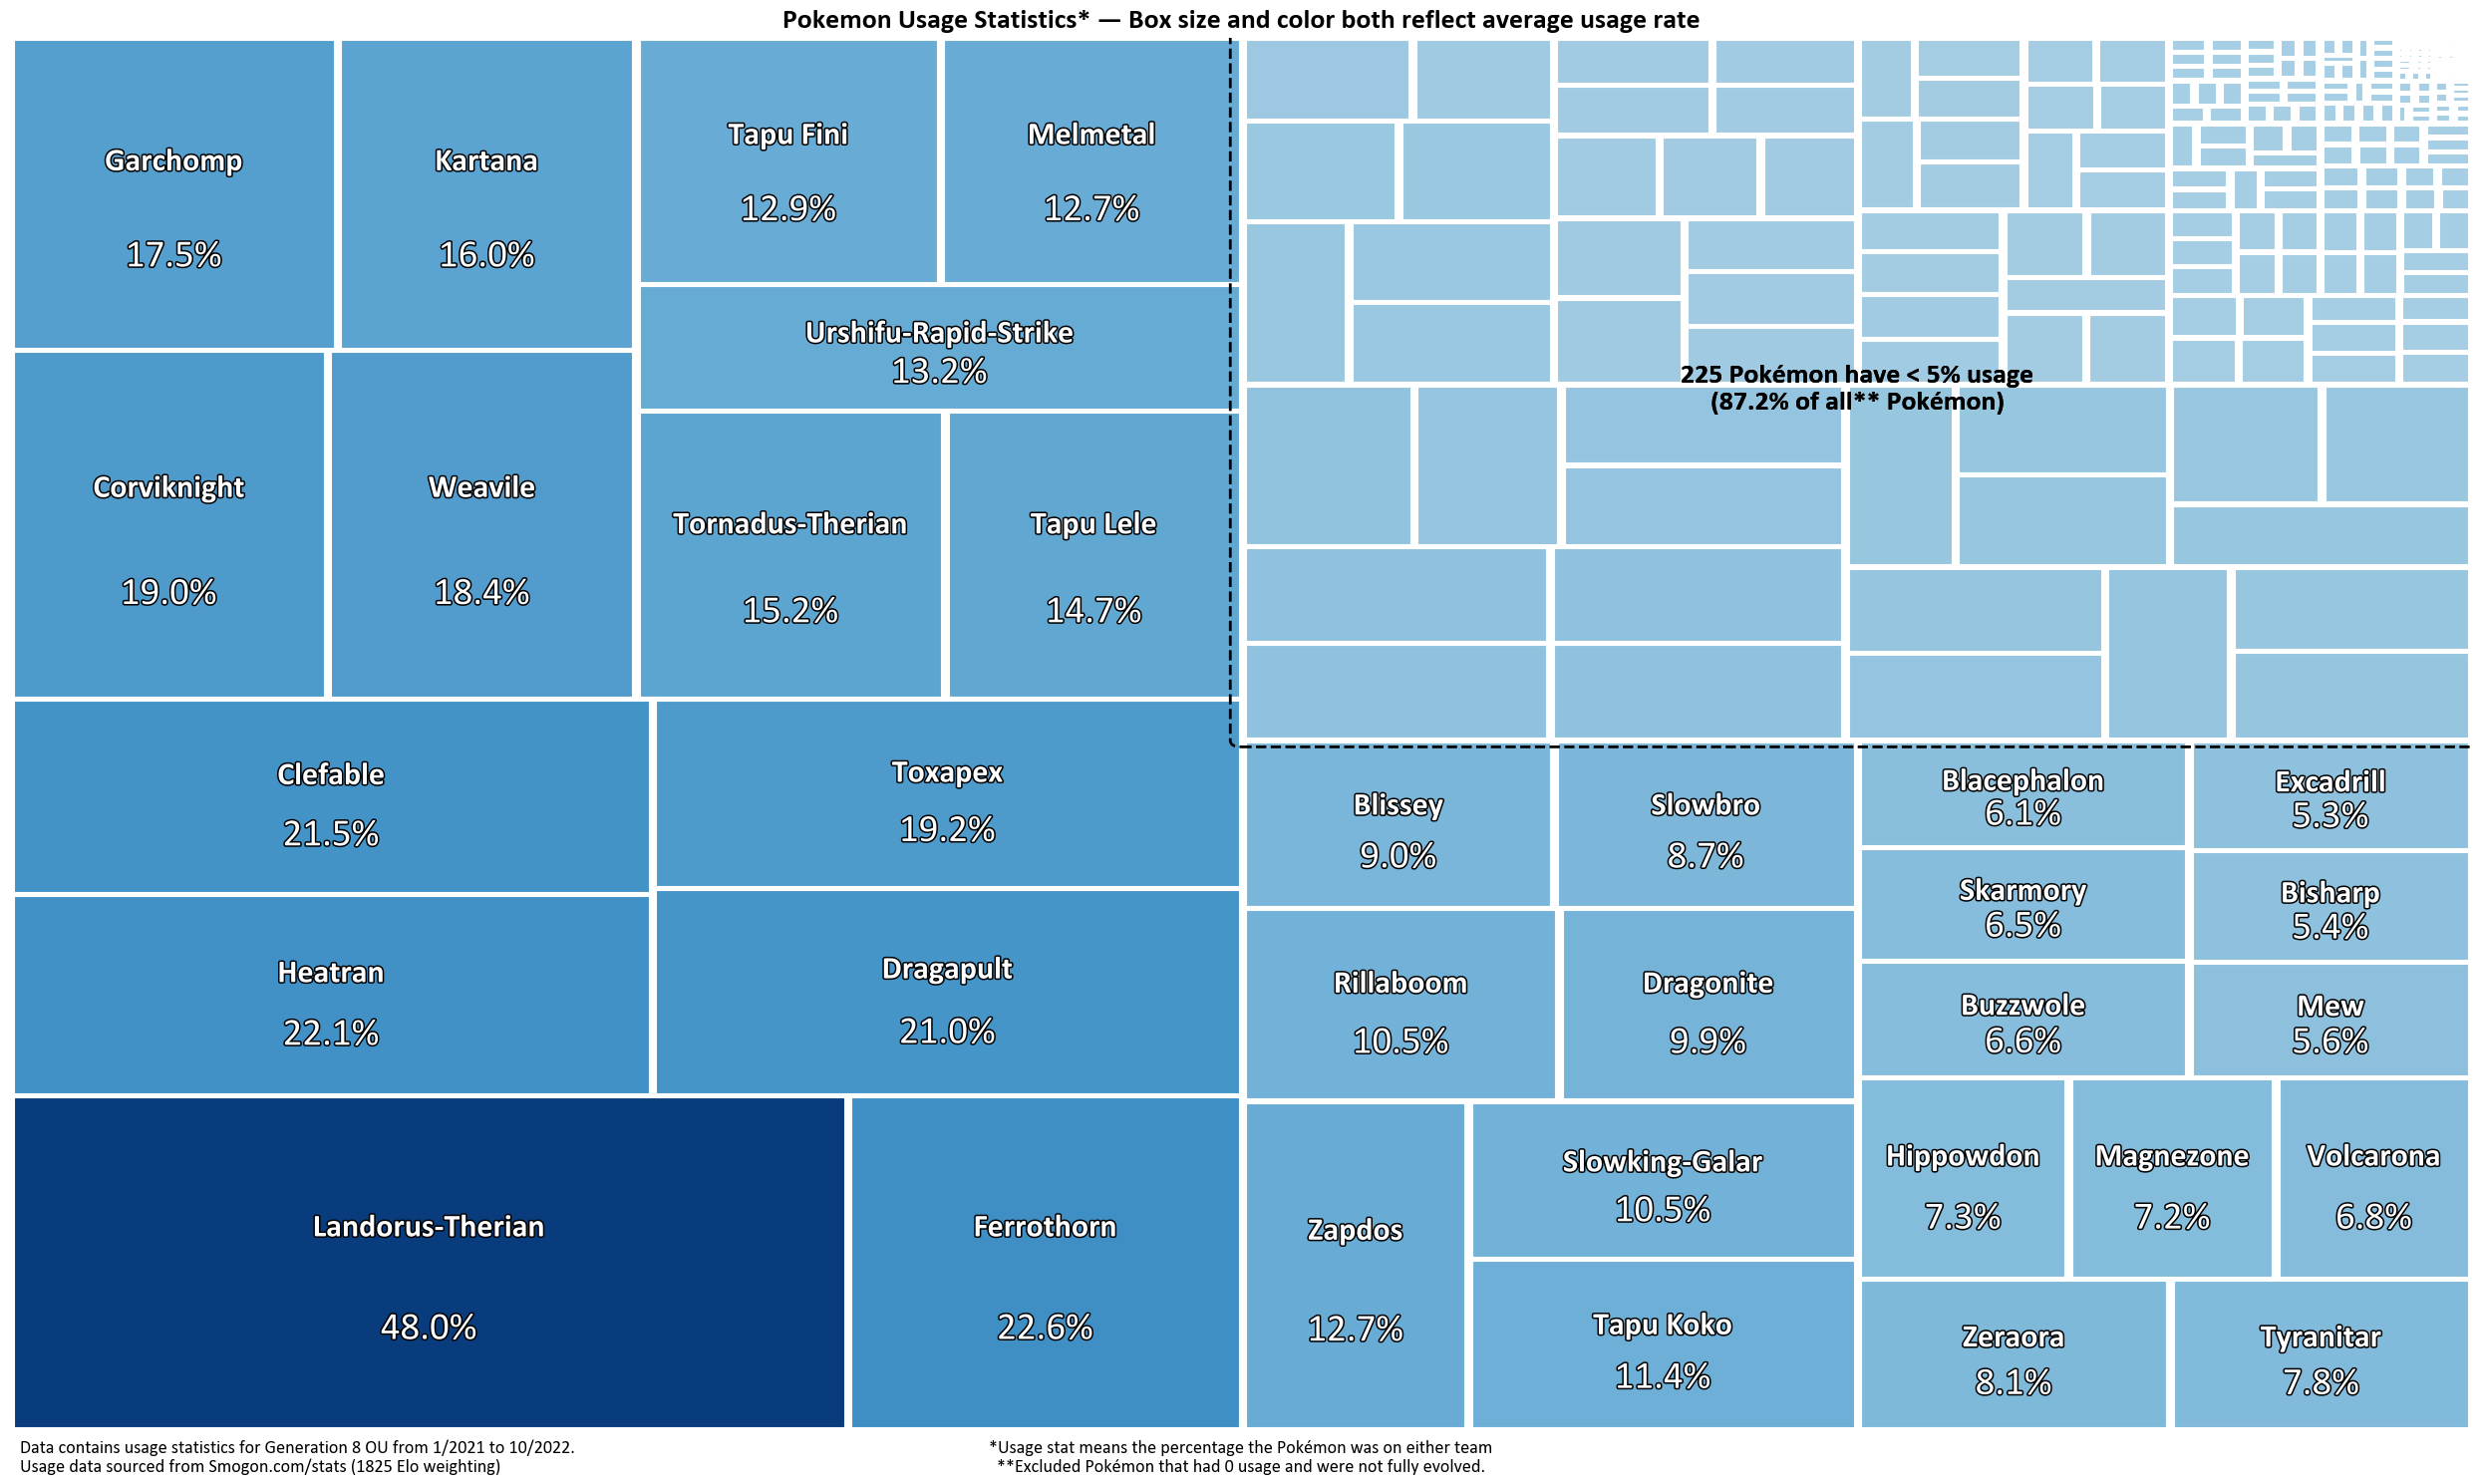

In [42]:
USAGE_LABEL_THRESHOLD = 5.2
plt.rcParams["font.family"] = "Calibri"

def _tm_layout(sizes, x, y, w, h):
    sizes = [float(s) for s in sizes if s > 0]

    def recurse(vals, x, y, w, h):
        n = len(vals)
        if n == 0:
            return []
        if n == 1:
            return [(x, y, w, h)]
        if n == 2:
            s0, s1 = vals
            total = s0 + s1
            if w >= h:
                w0 = w * (s0 / total)
                return [
                    (x, y, w0, h),
                    (x + w0, y, w - w0, h),
                ]
            else:
                h0 = h * (s0 / total)
                return [
                    (x, y, w, h0),
                    (x, y + h0, w, h - h0),
                ]

        total = sum(vals)
        half = total / 2

        running = 0
        split_idx = 0
        best_diff = float("inf")
        for i, v in enumerate(vals[:-1], start=1):
            running += v
            diff = abs(half - running)
            if diff < best_diff:
                best_diff = diff
                split_idx = i

        left = vals[:split_idx]
        right = vals[split_idx:]
        left_sum = sum(left)

        if w >= h:
            w_left = w * (left_sum / total)
            return (
                recurse(left, x, y, w_left, h) +
                recurse(right, x + w_left, y, w - w_left, h)
            )
        else:
            h_top = h * (left_sum / total)
            return (
                recurse(left, x, y, w, h_top) +
                recurse(right, x, y + h_top, w, h - h_top)
            )

    return recurse(sizes, x, y, w, h)


def _touch_or_close(r1, r2, tol=0.6):
    x1, y1, w1, h1 = r1
    x2, y2, w2, h2 = r2

    x1r, y1t = x1 + w1, y1 + h1
    x2r, y2t = x2 + w2, y2 + h2

    overlap_y = min(y1t, y2t) - max(y1, y2)
    overlap_x = min(x1r, x2r) - max(x1, x2)

    vertical_touch = abs(x1r - x2) <= tol or abs(x2r - x1) <= tol
    horizontal_touch = abs(y1t - y2) <= tol or abs(y2t - y1) <= tol

    return (vertical_touch and overlap_y > tol) or (horizontal_touch and overlap_x > tol)


def _largest_unlabeled_group(rects, labels_s, sizes_a):
    unlabeled = [(r, s) for r, lab, s in zip(rects, labels_s, sizes_a) if lab == ""]
    if not unlabeled:
        return None

    groups = []
    remaining = unlabeled[:]

    while remaining:
        seed = remaining.pop(0)
        group = [seed]
        changed = True

        while changed:
            changed = False
            keep = []
            for item in remaining:
                if any(_touch_or_close(item[0], g[0]) for g in group):
                    group.append(item)
                    changed = True
                else:
                    keep.append(item)
            remaining = keep

        groups.append(group)

    groups.sort(key=lambda g: len(g), reverse=True)
    return groups[0]


def _add_summary_box(ax, rects, labels_s, sizes_a, below_count, below_pct, threshold):
    group = _largest_unlabeled_group(rects, labels_s, sizes_a)
    if group is None:
        return
    unlabeled_rects = [r for r, lab in zip(rects, labels_s) if lab == ""]
    if not unlabeled_rects:
        return

    xs  = [r[0] for r in unlabeled_rects]
    ys  = [r[1] for r in unlabeled_rects]
    x2s = [r[0] + r[2] for r in unlabeled_rects]
    y2s = [r[1] + r[3] for r in unlabeled_rects]

    gx0, gy0 = min(xs), min(ys)
    gx1, gy1 = max(x2s), max(y2s)
    gw, gh = gx1 - gx0, gy1 - gy0

    cx = gx0 + gw / 2
    cy = gy0 + gh / 2
    box_w = gw + .1
    box_h = gh + .1
    bx0 = cx - box_w / 2
    by0 = cy - box_h / 2

    ax.add_patch(mpatches.FancyBboxPatch(
        (bx0, by0),
        box_w,
        box_h,
        boxstyle="round,pad=0.45",
        facecolor="none",
        edgecolor="black",
        linewidth=2.0,
        linestyle="--"
    ))

    fs = max(20, min(24, (gw * gh) ** 0.24))

    ax.text(
        cx,
        cy,
        f"{below_count} Pokémon have < {threshold:.0f}% usage\n({below_pct:.1f}% of all** Pokémon)",
        ha="center",
        va="center",
        fontsize=fs,
        fontweight="bold",
        color="black",
    )

    fs = max(20, min(24, (box_w * box_h) ** 0.24))
    stroke = []

    ax.text(
        cx,
        cy,
        f"{below_count} Pokémon have < {threshold:.0f}% usage\n({below_pct:.1f}% of all** Pokémon)",
        ha="center",
        va="center",
        fontsize=fs,
        fontweight="bold",
        color="black",
        path_effects=stroke
    )


def _tm_draw(ax, sizes_raw, labels, title, below_count, below_pct, threshold):
    sizes = np.array(sizes_raw, dtype=float)

    order = np.argsort(sizes)[::-1]
    sizes_s = sizes[order].tolist()
    labels_s = [labels[i] for i in order]
    sizes_a = np.array(sizes_s)

    cmap = cm.get_cmap("Blues")
    vmin, vmax = sizes_a.min(), sizes_a.max()
    if vmax > vmin:
        normed = (sizes_a - vmin) / (vmax - vmin)
    else:
        normed = np.zeros_like(sizes_a)
    colors_s = [cmap(0.35 + 0.6 * v) for v in normed]

    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.axis("off")

    rects = _tm_layout(sizes_s, 0, 0, 100, 100)

    BASE_FS = 10
    NAME_FS = BASE_FS * 2.3
    PCT_FS  = BASE_FS * 2.8

    for i, ((rx, ry, rdx, rdy), label, color) in enumerate(zip(rects, labels_s, colors_s)):
        ax.add_patch(mpatches.FancyBboxPatch(
            (rx + 0.15, ry + 0.15),
            rdx - 0.3,
            rdy - 0.3,
            boxstyle="square,pad=0",
            facecolor=color,
            edgecolor="white",
            linewidth=0.8
        ))

        if rdx < 4 or rdy < 3 or label == "":
            continue

        stroke = [pe.withStroke(linewidth=2.2, foreground="black")]

        ax.text(
            rx + rdx / 2,
            ry + rdy * 0.60,
            label,
            ha="center",
            va="center",
            fontsize=NAME_FS,
            fontweight="bold",
            color="white",
            path_effects=stroke,
            clip_on=True,
            rotation=0
        )

        if rdx > 6 and rdy > 4:
            ax.text(
                rx + rdx / 2,
                ry + rdy * 0.30,
                f"{sizes_a[i]:.1f}%",
                ha="center",
                va="center",
                fontsize=PCT_FS,
                color="white",
                path_effects=stroke,
                clip_on=True,
                rotation=0
            )

    _add_summary_box(
        ax,
        rects,
        labels_s,
        sizes_a,
        below_count=below_count,
        below_pct=below_pct,
        threshold=threshold
    )

    ax.set_title(title, fontsize=20, fontweight="bold", pad=8)


tm_plot_all = tm_full[tm_full["pokemon"].isin(tm_legal)].copy()

sizes_all = tm_plot_all["mean_pct"].clip(lower=0.01).tolist()
labels_all = [
    name if mean_val >= USAGE_LABEL_THRESHOLD else ""
    for name, mean_val in zip(tm_plot_all["pokemon"], tm_plot_all["mean_pct"])
]

total_pokemon = len(tm_plot_all)
below_threshold_count = sum(tm_plot_all["mean_pct"] < USAGE_LABEL_THRESHOLD)
below_threshold_pct = 100 * below_threshold_count / total_pokemon if total_pokemon > 0 else 0

tm_fig2, tm_ax2 = plt.subplots(figsize=(25, 15))
_tm_draw(
    ax=tm_ax2,
    sizes_raw=sizes_all,
    labels=labels_all,
    title="Pokemon Usage Statistics* — Box size and color both reflect average usage rate",
    below_count=below_threshold_count,
    below_pct=below_threshold_pct,
    threshold=USAGE_LABEL_THRESHOLD,
)

tm_fig2.text(
    0.5,
    0.01,
    f"*Usage stat means the percentage the Pokémon was on either team\n"
    f"**Excluded Pokémon that had 0 usage and were not fully evolved.",
    ha="center",
    va="bottom",
    fontsize=13
)
tm_fig2.text(
    0.01,
    0.01,
    f"Data contains usage statistics for Generation 8 OU from 1/2021 to 10/2022.\nUsage data sourced from Smogon.com/stats (1825 Elo weighting)",
    ha="left",
    va="bottom",
    fontsize=13
)

tm_fig2.tight_layout(rect=[0, 0.03, 1, 1.0])
tm_fig2.savefig(SAVE_DIR / "MeanTREE.png", dpi=150, bbox_inches="tight")
plt.show()

Treemap showing average Pokémon usage rates in Gen 8 OU competitive play from 2021–2022. Usage is heavily concentrated among a small number of Pokémon, where 223 out of 258 Pokémon (86.4%) averaged less than 5% usage across the entire period, while a handful of top-tier Pokémon dominate the majority of the chart's area.
